This notebook concentrates on algorithmic audio processing; see also ./recordings.ipynb ./tf.ipynb

# imports

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

In [2]:
import collections, os, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import pandas
import scipy.io.wavfile
import scipy.signal

import pyaudio
# import aubio
# import bob.ap

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
if 'cwd' not in globals():
    cwd = os.getcwd()
os.chdir(cwd)

import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

from smanmi import abase, audio, effects as E, hotplug, logic as L, notebook, signals as S, util
from nuru import features, recording, settings

plot_logmel = lambda logmel, *a, **kw: notebook.plot_logmel(
    logmel, rate=settings.rate, hop_size=settings.hop_size,
    lower_edge_hertz=settings.lower_edge_hertz, upper_edge_hertz=settings.upper_edge_hertz,
    *a, **kw)

Signal = L.Signal
Effect = E.Effect

audio.init(settings)

In [ ]:
audio.AudioInterface.list_devices()

In [ ]:
if 'p' in globals():
    p.terminate()
p = pyaudio.PyAudio()

# record

## simple

In [27]:
CHUNK = 1024

def record(name, secs, channels=1, rate=settings.rate, format=settings.dtype):
    """Records `secs` worth of audio and returns sample array."""
    global p
    input_stream = None
    for device in audio.AudioInterface.devices():
        if name.lower() in device['name'].lower():
            print(f'Recording {secs}s from "{device["name"]}"...')
            input_stream = p.open(
                output_device_index=device['index'],
                channels=channels,
                rate=rate,
                format=format,
                input=True,
            )
            break
    assert input_stream, f'Could not find device ~ "{name}"'
    # Empty buffer.
    while input_stream.get_read_available():
        input_stream.read(input_stream.get_read_available())

    frames = []
    for i in range(0, rate * secs // CHUNK):
        data = input_stream.read(CHUNK)
        frames.append(data)

    print("* done recording")

    return np.concatenate([
        np.frombuffer(frame, np.int16) for frame in frames])

def fromstereo(buf):
    """Returns `left, right` from stereo recording."""
    return buf.reshape([2, -1], order='F')

Recording 1s from "Built-in Microphone"...
* done recording


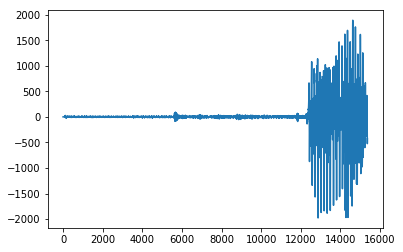

In [8]:
wav = record('microphone', 1)
plt.plot(wav)

In [9]:
ai = audio.AudioInterface(output=1)

In [12]:
ai.play(wav)

## nuru.recording

In [ ]:
os.chdir(cwd)
os.chdir('..')

rec = recording.Recording.from_name('test')
for chunk in util.Streamer(wav, buf_size=settings.buf_size, hop_size=settings.hop_size):
    feats = features.wav2features(util.int16_to_float(chunk), settings.hop_size)
    rec.append(feats)
rec.close()
rec.path

os.chdir(cwd)

In [ ]:
rec2 = recording.Recording.load(rec.path)

1


<BarContainer object of 50 artists>

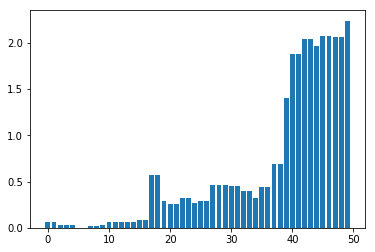

In [123]:
plt.bar(range(length), rec.envelope(length));

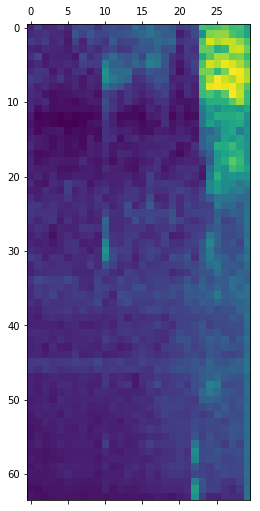

Exception ignored in: <function Wave_write.__del__ at 0x10e853170>
Traceback (most recent call last):
  File "/usr/local/Cellar/python/3.7.6_1/Frameworks/Python.framework/Versions/3.7/lib/python3.7/wave.py", line 327, in __del__
    self.close()
  File "/usr/local/Cellar/python/3.7.6_1/Frameworks/Python.framework/Versions/3.7/lib/python3.7/wave.py", line 445, in close
    self._ensure_header_written(0)
  File "/usr/local/Cellar/python/3.7.6_1/Frameworks/Python.framework/Versions/3.7/lib/python3.7/wave.py", line 465, in _ensure_header_written
    raise Error('sample width not specified')
wave.Error: sample width not specified
Exception ignored in: <function Wave_write.__del__ at 0x10e853170>
Traceback (most recent call last):
  File "/usr/local/Cellar/python/3.7.6_1/Frameworks/Python.framework/Versions/3.7/lib/python3.7/wave.py", line 327, in __del__
    self.close()
  File "/usr/local/Cellar/python/3.7.6_1/Frameworks/Python.framework/Versions/3.7/lib/python3.7/wave.py", line 444, in cl

In [90]:
plot_logmel(rec2.logmel)

### convert old

In [180]:
import glob
for path_in in glob.glob('../recordings/*.wav'):
    mtime = os.stat(path_in).st_mtime
    ymd = time.strftime('%Y%m%d_%H%M%S', time.localtime(mtime))
    path_out = f'../recordings/recorder/{ymd}_{path_in.split("/")[-1]}'
    if os.path.exists(path_out):
        os.unlink(path_out)
    rec = recording.convert(path_in, path_out)
    rec = recording.Recording(path_out)
    print(f'converted {path_in} -> {path_out} : {rec!r}')
    break

converted ../recordings/o_r_5.wav -> ../recordings/recording/20190526_165549_o_r_5.wav : Recording(hops=117, secs=3.7)


## stereo microphone

In [ ]:
wav2 = record('microphone', 1, channels=2)
wav2l, wav2r = fromstereo(wav2)
plt.plot(wav2l)
plt.plot(wav2l - wav2r)

## 2nd soundcard

In [53]:
!ls ../data/samples/44100

bouncer_125bpm_A_minor.wav	    haunting-ambience_D_major.wav
cruel-noise-pad_120bpm_A_major.wav  suspenseful-ambience_F_major.wav
dark-soundscape_138bpm_F_minor.wav


In [5]:
sr, wav16 = scipy.io.wavfile.read('../data/samples/16000/cruel-noise-pad_120bpm_A_major.wav')
len(wav16)/sr, sr

(16.0, 16000)

In [6]:
sr, wav44 = scipy.io.wavfile.read('../data/samples/44100/haunting-ambience_D_major.wav')
len(wav44)/sr, sr

(57.30374149659864, 44100)

In [7]:
sr, wav44_2 = scipy.io.wavfile.read('../data/samples/44100/cruel-noise-pad_120bpm_A_major.wav')
len(wav44_2)/sr, sr

(16.0, 44100)

In [8]:
sr, wav44_3 = scipy.io.wavfile.read('../data/samples/44100/bouncer_125bpm_A_minor.wav')
len(wav44_3)/sr, sr

(7.68, 44100)

In [8]:
# ai1 = audio.make_ai(settings.out1_names, #stream_callback=stream_callback1,
#                     rate=settings.out1_rate,
#                     frames_per_buffer=int(settings.hop_secs * settings.out1_rate))

In [12]:
# ai1.play(wav44[:3*44100])

In [22]:
# zeros = np.zeros(int(settings.out2_rate * settings.hop_secs))

In [24]:
# for i in range(50):
#     bufs = hp.effects.effector1(zeros, signals=dict(left_drone=1, right_drone=1))
#     ai1.output_stream.write(audio.tostereo(bufs[0], bufs[1]).tostring())

In [9]:
audio.AudioInterface.list_devices()

device_index=0 "HDA Intel HDMI: 0 (hw:0,3)", input=0, output=8
device_index=1 "HDA Intel HDMI: 1 (hw:0,7)", input=0, output=8
device_index=2 "HDA Intel HDMI: 2 (hw:0,8)", input=0, output=8
device_index=3 "HDA Intel HDMI: 3 (hw:0,9)", input=0, output=8
device_index=4 "HDA Intel HDMI: 4 (hw:0,10)", input=0, output=8
device_index=5 "HDA Intel PCH: ALC3232 Analog (hw:1,0)", input=2, output=4
device_index=6 "io|2: USB Audio (hw:2,0)", input=2, output=2
device_index=7 "C-Media USB Audio Device: - (hw:3,0)", input=1, output=2
device_index=8 "hdmi", input=0, output=8
device_index=9 "pulse", input=32, output=32
device_index=10 "default", input=32, output=32


In [47]:
if 'p' in globals():
    p.terminate()
p = pyaudio.PyAudio()

# what works:
# - input "io|2: USB Audio" 2 channels, variable rate
# - output "default" 2 channels, variable rate
# - 2x2 outputs : restart UBUNTU (again!) - then select
#   out: "HDA Intel PCH: ALC3232 Analog"
#   out2: "default" (need to select "C-Media USB Audio Device" shown as "... - Audio Adapter")
# what does NOT work - everything else, basically
# - output "HDA Intel PCH: ALC3232 Analog" : Invalid number of channels (ouptut=0 !)

In [41]:
out = p.open(
    output_device_index=5,  # HDA Intel PCH: ALC3232 Analog
#     output_device_index=10,  # default
#     output_device_index=6,  # C-Media USB Audio Device
    channels=2,
    output=True,
#     rate=16000,
    rate=44100,
    format=pyaudio.paInt16,
)

In [42]:
out2 = p.open(
#     output_device_index=7,  # io|2: USB Audio
    output_device_index=10,  # default
#     output_device_index=6,  # C-Media USB Audio Device
    channels=2,
    output=True,
    rate=44100,
    format=pyaudio.paInt16,
)

In [13]:
out.write(audio.tostereo(wav2l, zl(wav2r)).tostring())

NameError: name 'wav2l' is not defined

In [35]:
out.write(audio.tostereo(wav44[:3*44100], wav44_2[:3*44100]).tostring())

In [25]:
out.write(wav44[:3*44100].tostring())

In [46]:
out2.write(audio.tostereo(wav44[:3*44100], wav44_2[:3*44100]).tostring())

In [62]:
def zl(wav):
    return np.zeros(wav.shape, wav.dtype)

In [43]:
out2.write(audio.tostereo(zl(wav44[:3*44100]), (wav44[:3*44100])).tostring())

NameError: name 'zl' is not defined

In [131]:
out2.write(wav44[:3*44100].tostring())

## manual

In [6]:
audio_interface = audio.AudioInterface(input=1, output=1)
settings.to_string()

'rate=16000 buf_secs=0.064s (1024) hop_secs=0.032s (512) '

* recording
* done recording


(47104, 2.944)

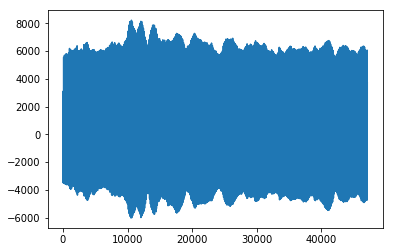

In [27]:
# record ...
data = audio_interface.record(secs=3)
plt.plot(data)
len(data), len(data)/settings.rate

In [28]:
audio_interface.play(data)

In [94]:
# store recording...
scipy.io.wavfile.write('../recordings/t_a_5.wav', rate, data)
# !ls -lh ../recordings/*

-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 21:46 ../recordings/a_welle.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:14 ../recordings/o_a_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:56 ../recordings/o_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_3.wav
-rw-

In [76]:
p = pyaudio.PyAudio()
pyaudio.Stream()

# samples

In [7]:
import glob
samples = {
  path.split('/')[-1][:-4]: path
  for path in glob.glob('../data/samples/16000/*.wav')
}
print('\n'.join(samples.keys()))

dark-soundscape_138bpm_F_minor
haunting-ambience_D_major
cruel-noise-pad_120bpm_A_major
suspenseful-ambience_F_major


In [8]:
sr, wav = scipy.io.wavfile.read(samples['cruel-noise-pad_120bpm_A_major'])
wav = util.int16_to_float(wav)
assert sr == settings.rate
len(wav) / sr

16.0

In [9]:
ai = audio.AudioInterface(output=1, rate=16000)

In [10]:
ai.play(wav[:2*16000])

In [11]:
?timeit

Docstring:
Time execution of a Python statement or expression

Usage, in line mode:
  %timeit [-n<N> -r<R> [-t|-c] -q -p<P> -o] statement
or in cell mode:
  %%timeit [-n<N> -r<R> [-t|-c] -q -p<P> -o] setup_code
  code
  code...

Time execution of a Python statement or expression using the timeit
module.  This function can be used both as a line and cell magic:

- In line mode you can time a single-line statement (though multiple
  ones can be chained with using semicolons).

- In cell mode, the statement in the first line is used as setup code
  (executed but not timed) and the body of the cell is timed.  The cell
  body has access to any variables created in the setup code.

Options:
-n<N>: execute the given statement <N> times in a loop. If <N> is not
provided, <N> is determined so as to get sufficient accuracy.

-r<R>: number of repeats <R>, each consisting of <N> loops, and take the
best result.
Default: 7

-t: use time.time to measure the time, which is the default on Unix.
This f

In [12]:
%timeit -n5 -r5 logmel = features.log_mel_spectrogram(wav, audio_sample_rate=16000)

15.3 ms ± 5.88 ms per loop (mean ± std. dev. of 5 runs, 5 loops each)


In [89]:
logmel.shape

(499, 64)

In [106]:
a = np.arange(10)
(a > 3).argmax()

4

In [96]:
from audioset import mel_features


def mel_to_hertz(frequencies_mel):
  """Convert frequencies from mel scale to Hz using HTK formula.

  Args:
    frequencies_mel: Scalar or np.array of frequencies in mel.

  Returns:
    Object of same size as frequencies_mel containing corresponding values
    on the Hz scale.
  """
  return mel_features._MEL_BREAK_FREQUENCY_HERTZ * (
      np.exp(frequencies_mel / mel_features._MEL_HIGH_FREQUENCY_Q) - 1.0)



mels = np.linspace(settings.lower_edge_hertz, settings.upper_edge_hertz, logmel.shape[1] + 2)[1:-1]
mel_to_hertz(mels)


array([1.64948517e+02, 2.56562099e+02, 3.57879203e+02, 4.69927609e+02,
       5.93843953e+02, 7.30885263e+02, 8.82441709e+02, 1.05005070e+03,
       1.23541250e+03, 1.44040744e+03, 1.66711503e+03, 1.91783502e+03,
       2.19511076e+03, 2.50175498e+03, 2.84087834e+03, 3.21592094e+03,
       3.63068729e+03, 4.08938485e+03, 4.59666671e+03, 5.15767884e+03,
       5.77811222e+03, 6.46426065e+03, 7.22308451e+03, 8.06228144e+03,
       8.99036441e+03, 1.00167480e+04, 1.11518441e+04, 1.24071672e+04,
       1.37954516e+04, 1.53307803e+04, 1.70287278e+04, 1.89065184e+04,
       2.09832008e+04, 2.32798412e+04, 2.58197370e+04, 2.86286534e+04,
       3.17350845e+04, 3.51705425e+04, 3.89698771e+04, 4.31716295e+04,
       4.78184229e+04, 5.29573953e+04, 5.86406770e+04, 6.49259204e+04,
       7.18768839e+04, 7.95640793e+04, 8.80654867e+04, 9.74673458e+04,
       1.07865031e+05, 1.19364017e+05, 1.32080953e+05, 1.46144840e+05,
       1.61698346e+05, 1.78899247e+05, 1.97922033e+05, 2.18959673e+05,
      

In [101]:
(mel_features.hertz_to_mel(np.array([300., 600., 900.])),
 mel_to_hertz(mel_features.hertz_to_mel(np.array([300., 600., 900.])))
)

(array([401.97266182, 697.65718787, 931.66675198]), array([300., 600., 900.]))

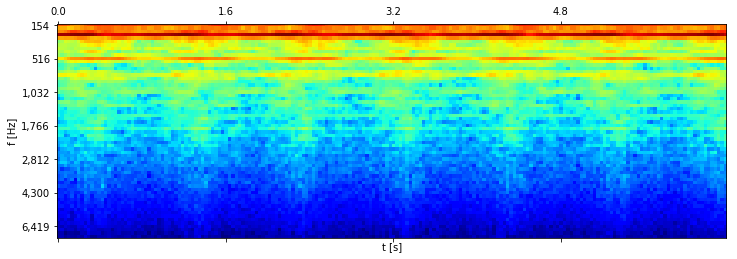

In [130]:
x, y = plot_logmel(logmel[:200])

# features

In [51]:
import time

time.process_time_ns()

115422156000

In [48]:
scipy.fft.rfft(wav[:settings.buf_size]).shape

(513,)

In [32]:
%timeit np.fft.rfft(wav[:settings.buf_size])

22.1 µs ± 924 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [29]:
%timeit features.log_mel_spectrogram(wav[:settings.buf_size], audio_sample_rate=16000)

1.57 ms ± 92 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [31]:
# more like 3.5 ms in recorder.py ?!
%timeit features.wav2features(wav[:settings.buf_size], settings.hop_size)

1.89 ms ± 227 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [46]:
%timeit features.wav2features(wav[:settings.buf_size], settings.hop_size)

101 µs ± 12.2 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


## synthetic FFT

(1.6, 2.0)

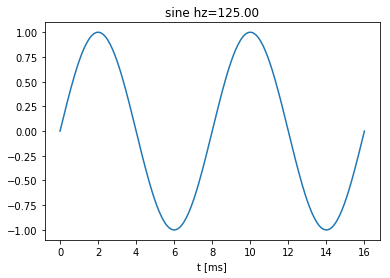

In [81]:

rate = 16000
buf_size = 256

hz = 100
n = buf_size / rate * hz
n0 = np.round(n)
# nearest frequency that fits beginning-to-end
hz0 = n0 / buf_size * rate

t = np.linspace(0, buf_size / rate, buf_size)

buf = np.sin(t * 2 * np.pi * hz0)

plt.plot(t * 1e3, buf)
plt.gca().set_xlabel('t [ms]')
plt.gca().set_title(f'sine hz={hz0:.2f}')

n, n0

buf size 256 zero + positive FFT 129
lowest freqs [  0.   62.5 125.  187.5 250.  312.5 375.  437.5 500.  562.5]
zero-offset 0.000
peak abs=127.736 at hz=125.0


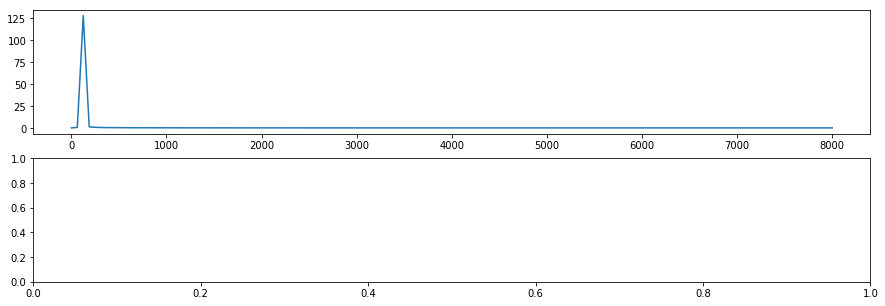

In [82]:
fft = np.fft.rfft(buf)
print('buf size', len(buf), 'zero + positive FFT', len(fft))

fmax = rate / 2
freqs = np.linspace(0, fmax, len(fft))
print('lowest freqs', freqs[:10])

fig, axs = plt.subplots(2, 1, figsize=(15, 5))

axs[0].plot(freqs, np.abs(fft))

print(f'zero-offset {np.abs(fft[0]):.3f}')
peak_i = fft.argmax()
print(f'peak abs={np.abs(fft[peak_i]):.3f} at hz={freqs[peak_i]}')

# analyze

## from abase

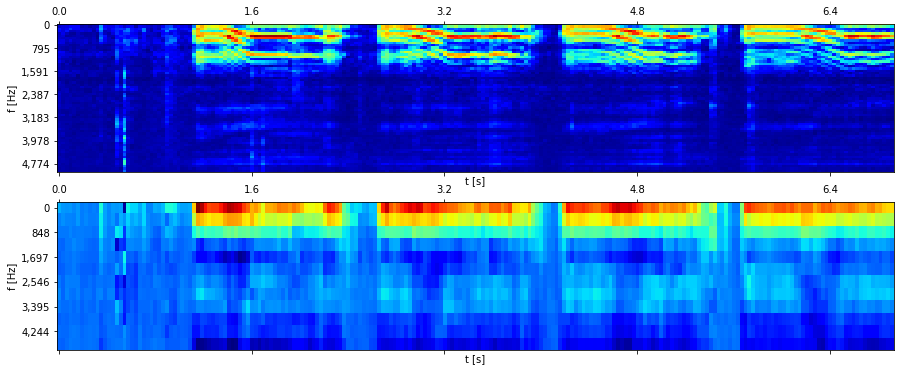

In [9]:
plt.figure(figsize=(15, 6))
plot_logmel(ab.df.loc['o_p_4', 'logmel'], ax=plt.subplot(211), aspect='auto')
plot_logmel(ab.df.loc['o_p_4', 'mfccs'], ax=plt.subplot(212), aspect='auto')

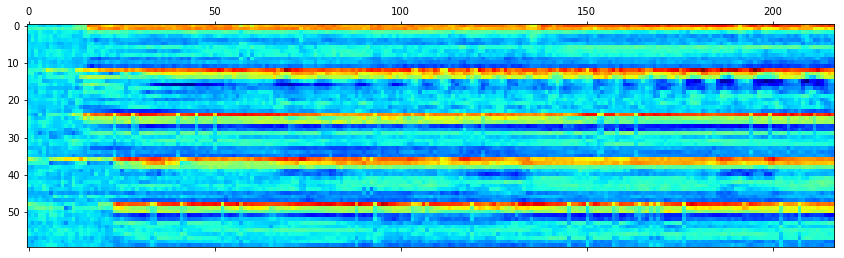

In [292]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "o"').sample(5)].mfccs.values).T, cmap='jet')

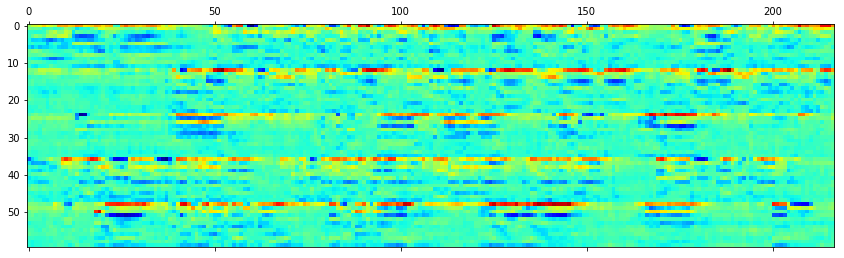

In [293]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "t"').sample(5)].mfccs.values).T, cmap='jet')

## signals

incubating ... to be moved to "signal" module

### plot utils

In [311]:
def plot_signals(row, signals1, signals2=(), cols='krgbmcy', hzmax=None):
    """Displays logmel and values derived from signals1,2 on twin axes."""
    plt.figure(figsize=(15, 6))
    util.plot_logmel(row.logmel, ax=plt.subplot(211), aspect='auto', hzmax=hzmax)
    i = 0
    signals = list(signals1) + list(signals2)
    values = [[] for _ in signals]
    for buf in util.Streamer(row.wav):
        feats = features.wav2features(buf)
        for i, signal in enumerate(signals):
            values[i].append(signal(feats))
    axs = [plt.subplot(212)]
    axs.append(axs[0].twinx())
    for i, signal in enumerate(signals):
        axs[i >= len(signals1)].plot(
            values[i], cols[i % len(cols)] + ('-' if i < len(signals1) else '--'))
    return values

def plot_dfs(df_by_col, signals):
    """Plots signal in separate graphs from dataframe rows with different colors."""
    assert len(signals) > 1
    _, axs = plt.subplots(len(signals), 1, figsize=(15, 10))
    for col, df in df_by_col.items():
        for _, row in df.iterrows():
            values = [[] for _ in signals]
            for buf in util.Streamer(row.wav):
                feats = features.wav2features(buf)
                for i, signal in enumerate(signals):
                    values[i].append(signal(feats))
            for i, value in enumerate(values):
                axs[i].plot(value, col)

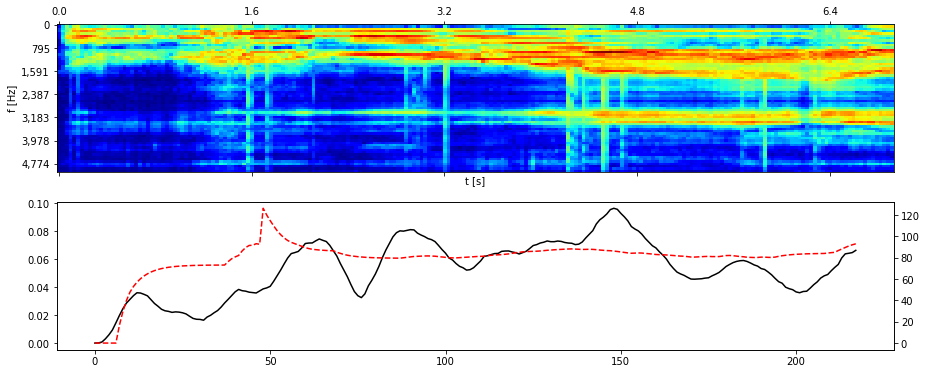

In [312]:
vs = plot_signals(ab.data.o_a_3, [
    # 0..1 axis
    S.Louder(n=10) | S.F(mult=10),
#     ThresholdedFrequencies(hz=2000, threshold=-1, bins=3)
], [
    # freq axis
    S.Pitcher() | S.Limiter(maxv=300) | S.Exponential(alpha=25*0.8),
#     WeightedAverage(),
])

### utility signals

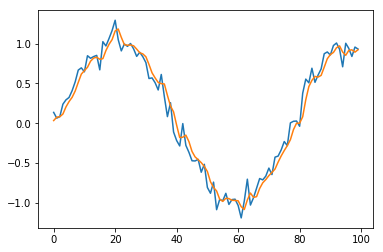

In [315]:
x = np.sin(np.linspace(0, 8, 100)) + np.random.normal(scale=0.1, size=100)
plt.plot(x)
h = S.Hamming(5)
plt.plot([h(_) for _ in x])

### base freq

Follow the lowest peak above threshold.

Does not work very well because : with harmonics, the max value is both
sensitive to the width of the band and to the number of harmonics; will be
much worse with noise...

In [259]:
ts = [3.4, 3.6, 3.8, 4.0]
row = ab.data.o_p_3

# base freq: not as clear ...
ts = [2.9, 3.0, 3.1, 3.2, 3.3]
row = ab.data.w_a_1

# base freq: more harmonics; goes down with peaks=5, but up with peaks=3
ts = [3.0, 3.1, 3.2, 3.3, 3.4, 3.5]
row = ab.data.o_g_2

In [206]:
row.play()

In [260]:
logmel256 = features.log_mel_spectrogram(row.wav, num_mel_bins=256, window_length_secs=0.256)
logmel = row.logmel

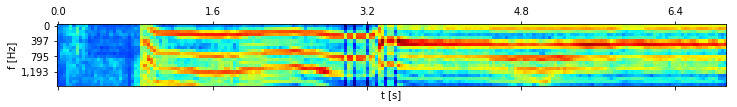

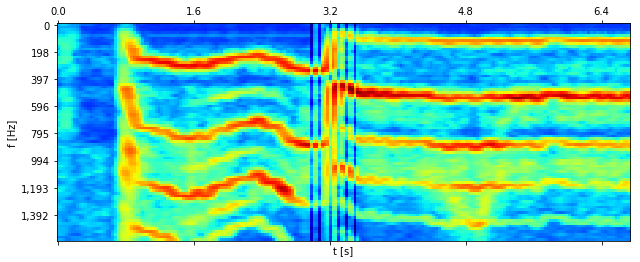

In [261]:
def plot_with(logmel, ts, hzmax=1600, ax=None):
    xs = [int(t * settings.rate / settings.hop_size) for t in ts]
    logmel_mod = logmel.copy()
    for x in xs:
        logmel_mod[x, :] -= 2
    util.plot_logmel(logmel_mod, hzmax=hzmax, ax=ax)

plot_with(logmel, ts)
plot_with(logmel256, ts)

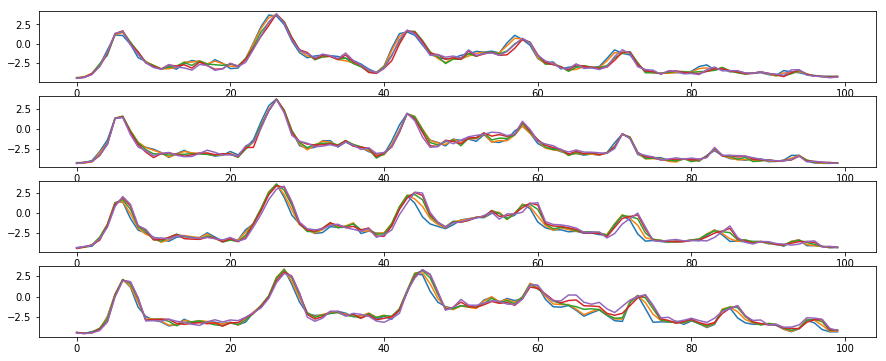

In [207]:
_, axs = plt.subplots(len(xs), 1, figsize=(15, 6))
for i, x in enumerate(xs):
    for dx in range(5):
        axs[i].plot(logmel256[x + dx, :100])

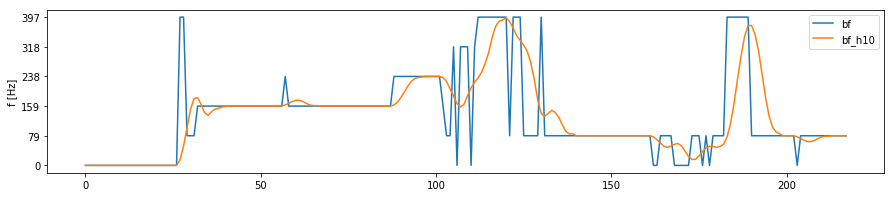

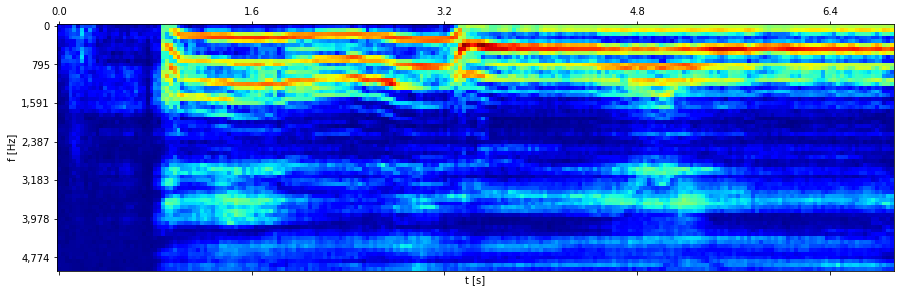

In [274]:
class BaseMax(Signal):
    def __init__(self, threshold, fmax=0, peaks=5, which='logmel'):
        self.threshold = threshold
        self.peaks = peaks
        self.which = which
        self.fmax = fmax

    def __call__(self, feats):
        logmel = getattr(feats, self.which)
        fmax = self.fmax if self.fmax else len(logmel)
        logmel = logmel[:fmax]
        logmel *= logmel > self.threshold
        if logmel.sum() == 0:
            return 0
        return logmel[:fmax].argsort()[-self.peaks:].min()


hzmax = 0
plt.figure(figsize=(15, 3))
for name, values in util.get_signals(row.wav, {
    'bf': BaseFreq(-0.5),
    'bf_h10': BaseFreq(-0.5) | S.Hamming(10),
#     'bf2': BaseFreq(-0.5, which='logmel2') | S.F(mult=1/4),
#     'bf2_h10': BaseFreq(-0.5, which='logmel2') | S.Hamming(10) | S.F(mult=1/4),
}).items():
    plt.plot(values, label=name)
plt.gca().set_yticklabels([
    '{:,}'.format(int(f * settings.f2hz))
    for f in plt.gca().get_yticks()
])
plt.gca().set_ylabel('f [Hz]')
plt.legend()

plt.figure(figsize=(15, 7))
plot_with(logmel, [], ax=plt.gca(), hzmax=hzmax);

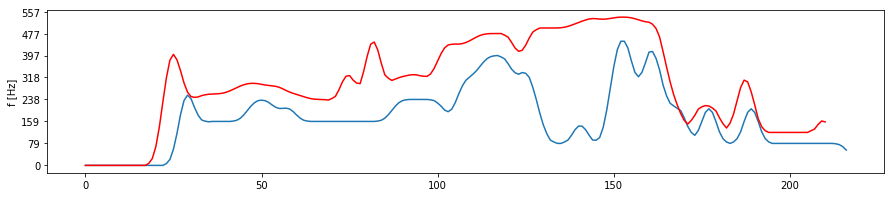

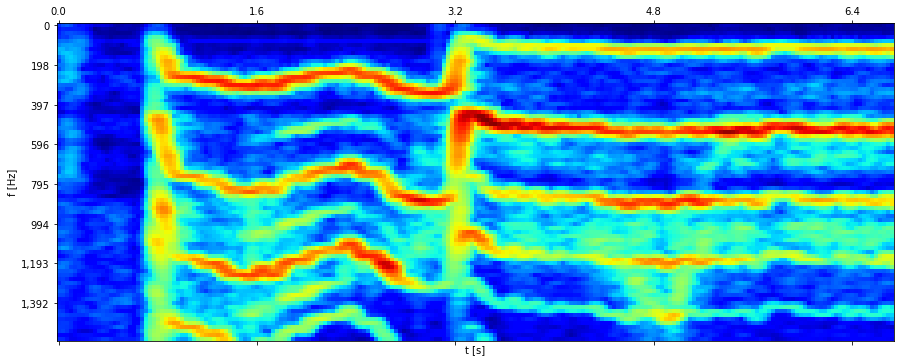

In [213]:
def smooth(vs, n=10):
    w = np.hamming(n)
#     w = np.ones(n)
    return numpy.convolve(vs, w, mode='same')/w.sum()

def get_base_freq(logmel, threshold=-0.5, peaks=4):
    vs = []
    for t, fs in enumerate(logmel):
        m = fs.argsort()[-peaks:].min()
        vs.append(m * (fs[m] > threshold))
    return np.array(vs)

plt.figure(figsize=(15, 3))
plt.plot(smooth(get_base_freq(logmel[:, :])))
plt.plot(smooth(get_base_freq(logmel256[:, :]))/4, 'r')

plt.figure(figsize=(15, 7))
plot_with(logmel256, [], ax=plt.gca())
None

### base follower

### freq bands

In [314]:
row = ab.data.w_a_1

In [ ]:
row.play()

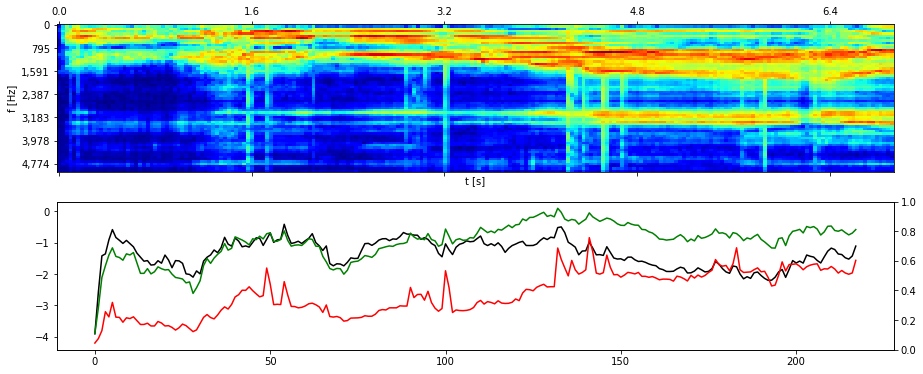

In [340]:
plot_signals(row, [
    S.FreqBand(hzmin=0, hzmax=800, hzslope=50),
    S.FreqBand(hzmin=800, hzmax=1e10, hzslope=50),
    S.FreqBand(hzmin=400, hzmax=1600, hzslope=50),
], [], hzmax=None);

### freq breadth

In [316]:
row = ab.data.o_a_3

In [335]:
row.play()

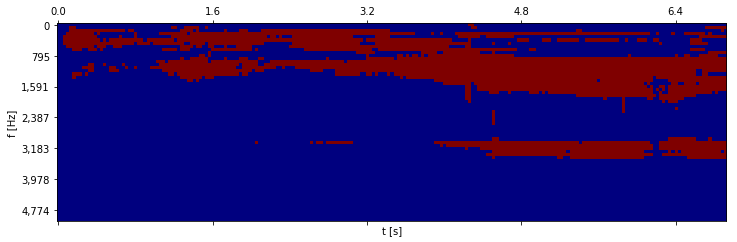

In [334]:
util.plot_logmel(row.logmel > -1)

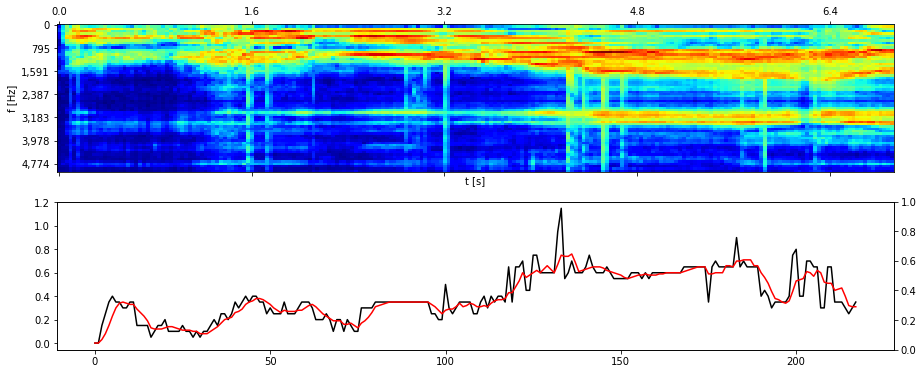

In [329]:
plot_signals(row, [
    S.FreqBreadth(-1) | S.F(mult=1/20),
    S.FreqBreadth(-1) | S.F(mult=1/20) | S.Clip(0, 1) | S.MovingAverage(5),
], [], hzmax=None);

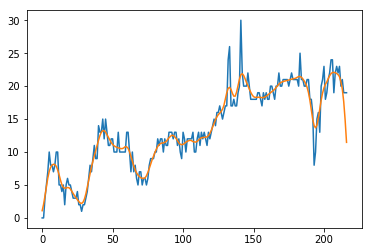

In [462]:
x = (ab.data.o_a_3.logmel > -1).sum(axis=1)
plt.plot(x)
w = np.hamming(11)
plt.plot(numpy.convolve(x, w, mode='same')/w.sum())

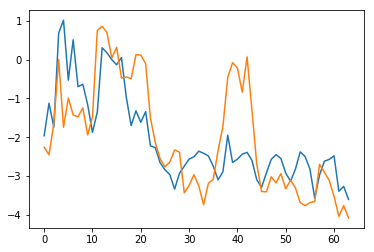

In [443]:
plt.plot(ab.data.o_a_3.logmel[int(1.6/settings.hop_secs), :])
plt.plot(ab.data.o_a_3.logmel[int(4.8/settings.hop_secs), :])

## plot

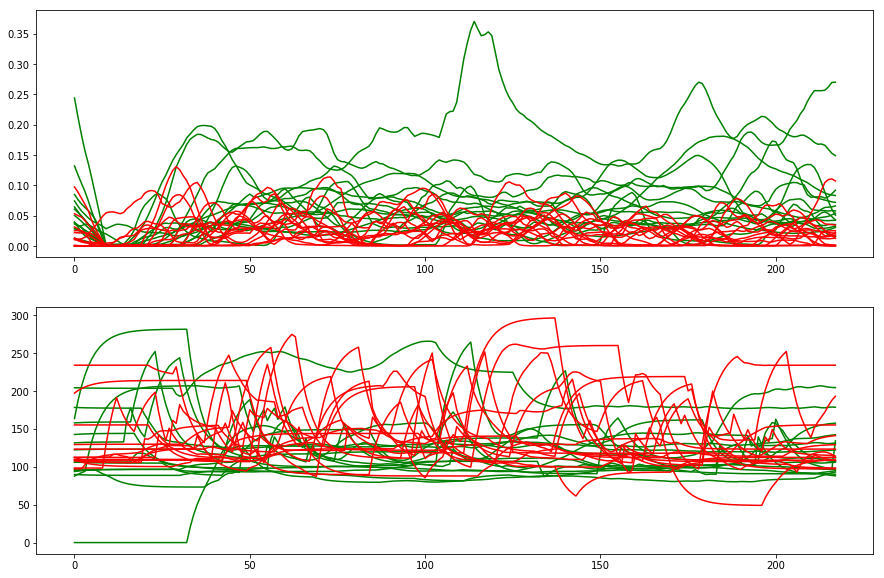

In [17]:
plot_dfs(dict(
    g=ab.df.query('what == "o"'),
    r=ab.df.query('what == "t"'),
), (
    S.Louder(n=10) | S.F(mult=10),
    S.Pitcher() | S.Limiter(maxv=300) | S.Exponential(alpha=25*0.8),
))

# effects

incubating ... before moving to `effects` module

## stereo

In [22]:
class PanSinusEffect:
    def __init__(self, period_s=4):
        self.period_s = period_s
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype != settings.dtype_np
#         assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        v = (1 + np.sin(self.i * settings.hop_secs / self.period_s * 2 * np.pi)) / 2
        self.i += 1
        left = buf * v
        right = buf * (1 - v)
        return np.vstack([left, right]).reshape(-1, order='F')

class RightDelayEffect:
    def __init__(self, delay_s=2):
        self.delay_s = delay_s
        self.delay_effect = EchoDelayEffect(delay_s=delay_s, coeff=0)

    def __call__(self, buf):
        assert buf.dtype != settings.dtype_np
#         assert len(buf) == settings.buf_size
        left = buf[: settings.hop_size]
        right = self.delay_effect(buf)
        return np.vstack([left, right]).reshape(-1, order='F')

class MonoToStereoEffect:
    def __call__(self, buf):
        assert buf.dtype != settings.dtype_np
#         assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        return np.vstack([buf, buf]).reshape(-1, order='F')

audio_interface = audio.AudioInterface(input=1, output=2)
effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['t_g_1', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## compose

In [275]:
audio_interface = audio.AudioInterface(output_channels=2)
# effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['o_p_5', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## pitch shift

## frequency filters

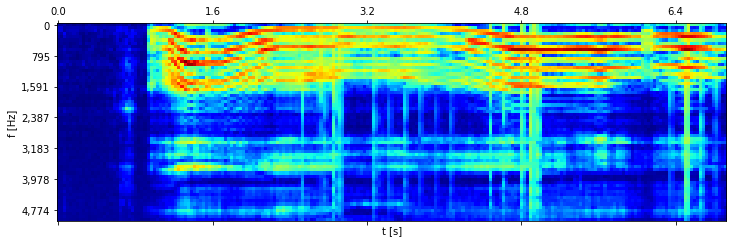

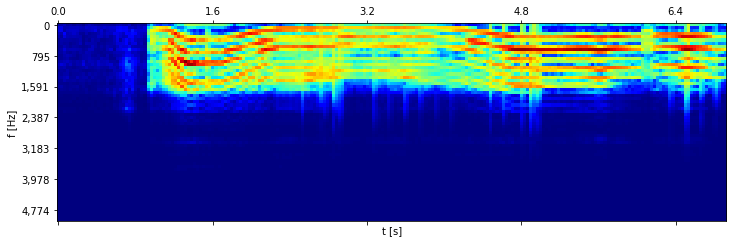

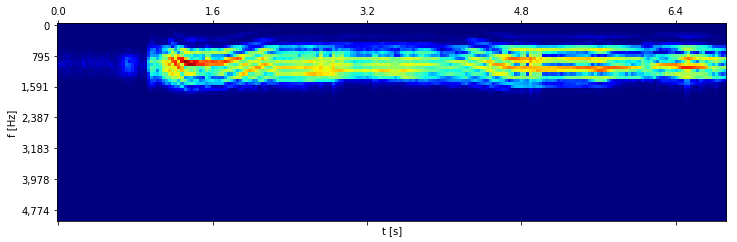

In [59]:
row = ab.data.o_a_1
util.plot_logmel(row.wav)

util.plot_logmel(util.apply_effect(row.wav, E.LowPass(hz=1000, order=5)))
util.plot_logmel(util.apply_effect(row.wav, E.BandPass(hz1=500, hz2=800, order=5)))

## sampled

In [68]:
# E.RndSub

## live

In [13]:
audio.AudioInterface.list_devices()

device_index=0 "Built-in Microphone", input=2, output=0 // None
device_index=1 "Built-in Output", input=0, output=2 // None


In [74]:
print('\n'.join(samples.keys()))

dark-soundscape_138bpm_F_minor
cruel-noise-pad_120bpm_A_major
haunting-ambience_D_major


In [79]:
samples['haunting-ambience_D_major']

'../data/samples/haunting-ambience_D_major_16.wav'

In [78]:
secs, recording_secs = 60, 0
sec = 0

buf = util.RollingBuffer(settings.buf_size)

sr, wav = scipy.io.wavfile.read(samples['haunting-ambience_D_major'])
print(len(wav)/sr)
assert sr == settings.rate
wav = util.int16_to_float(wav)

effector = E.Effector([
#   E.Silence(),
  E.RndSub(wav, sample_minmax=[3, 8], break_minmax=[1, 20], ramp_minmax=[2, 4]),
  E.RndSub(wav, sample_minmax=[3, 8], break_minmax=[1, 20], ramp_minmax=[2, 4]),
#     E.Echo(0.1, 0.9),
#     E.Echo(0.1, 0.9) | E.Delay(0.5),
], buf_size=int(recording_secs * settings.rate))

ai0 = audio.AudioInterface(input=1, device_index=0)
ai1 = audio.AudioInterface(output=2, device_index=1)

while sec < secs:
    data = ai0.input_stream.read(settings.hop_size, exception_on_overflow=False)
    data = np.frombuffer(data, settings.dtype_np)
    data = util.int16_to_float(data)
    buf(data)
    feats = features.wav2features(buf.buf)
    signals= hp.signals.runner(features=feats, t=time.time())

    bufs = effector(data, signals)
    buf1 = audio.tostereo(bufs[0], bufs[1])
    ai1.output_stream.write(buf1.tostring())
    sec += settings.hop_secs

57.30375


NameError: name 'random' is not defined

In [28]:
buf.buf.shape, len(effector.bufs), effector.bufs[0].buf.shape

((1024,), 2, (112000,))

In [19]:
features.log_mel_spectrogram(buf.buf);

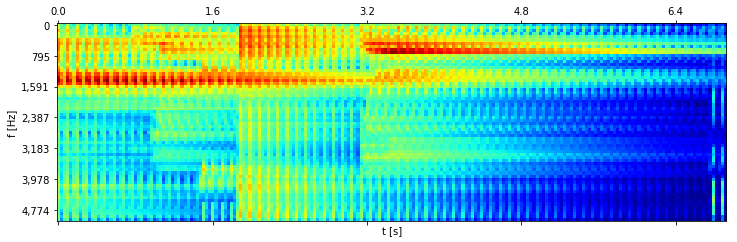

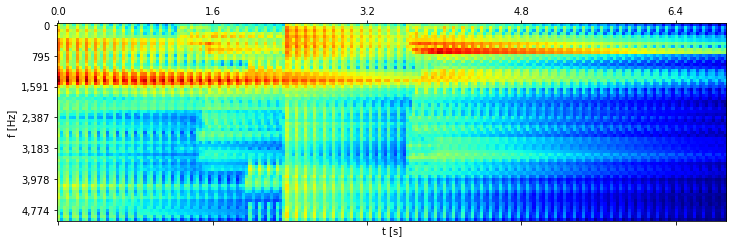

In [15]:
for recording in effector.bufs:
    logmel = features.log_mel_spectrogram(recording.buf)
    util.plot_logmel(logmel)

# feedback

In [260]:
def live_loop(secs, hop_size=settings.hop_size, filters=()):
    zfs = [
        scipy.signal.lfiltic(*ba, [])
        for ba in filters
    ]
    print('Recording {:.1} secs hop_size={} ({}ms)'.format(
        secs, hop_size, int(hop_size*settings.rate)
    ))
    ai = audio.AudioInterface(input=1, output=1)
    hop_size = settings.hop_size // 2
    n = int(np.ceil(secs * settings.rate / hop_size)) * hop_size
    recording = np.zeros(n, dtype=np.float32)
    i = 0
    while i < n:
        buf = ai.input_stream.read(hop_size, exception_on_overflow=False)
        buf = util.int16_to_float(np.frombuffer(buf, settings.dtype_np))
        assert len(buf) == hop_size
        recording[i: i + hop_size] = buf
        ai.output_stream.write(util.float_to_int16(buf.tostring()))
        i += settings.hop_size
    del ai
    return recording

Q = 3
filters = [
    scipy.signal.iirnotch(w0=1444, Q=Q, fs=settings.rate),
    scipy.signal.iirnotch(w0=2807, Q=Q, fs=settings.rate),
]

In [ ]:
recording_32ms = live_loop(secs=10, hop_size=settings.hop_size)

In [190]:
recording_16ms = live_loop(secs=10, hop_size=settings.hop_size//2)

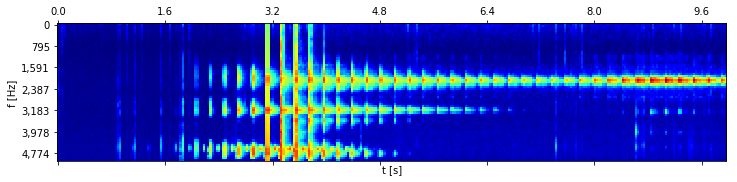

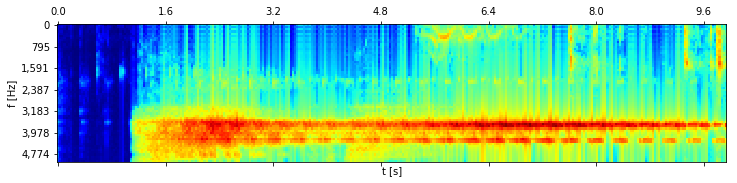

In [191]:
util.plot_logmel(features.log_mel_spectrogram(recording_32ms))
util.plot_logmel(features.log_mel_spectrogram(recording_16ms))

In [289]:

def plothz(hz, c='r'):
    import random
    ax = plt.gca()
    yl = ax.get_ylim()
    ax.plot([hz, hz], yl, c + '--')
    ax.text(hz * 1.1, yl[1] - random.random() * (yl[1] - yl[0]),
            '{} Hz'.format(int(hz)), dict(color=c), withdash=True)
    

def annotate_peaks(R, n=3, dbneg=0, mindfr=1.3, ax=None, rate=settings.rate):
    if ax is None:
        ax = plt.gca()
    peaks = set()
    yl = ax.get_ylim()
    for peak in np.argsort(-R):
        peakhz = peak / R.shape[0] * rate / 2
        keep = True
        for other in peaks:
            if other/peakhz < mindfr and peakhz/other < mindfr:
                keep = False
                break
        if not keep:
            continue
        peaks.add(peakhz)
        if R[peak] < -dbneg or len(peaks) > n:
            ax.set_ylim(yl)
            return
        plothz(peakhz)
    

def plot_freq(recording, min_secs, secs0=0, win=np.hamming, ax=None):
    n = 2
    i0 = int(settings.rate * secs0)
    while n < settings.rate * min_secs and n * 2 + i0 <= len(recording):
        n <<= 1
    r = recording[i0: i0 + n]
    r = win(len(r)) * recording[i0: i0 + n]
    if ax is None:
        plt.figure(figsize=(16, 4))
        ax = plt.gca()
    R = 20 * np.log10(np.absolute(np.fft.rfft(r)))
    ax.plot(np.linspace(0, settings.rate/2, R.shape[0]), R)
    ax.set_xscale('log')
    ax.set_xlabel('f [Hz]')
    ax.set_ylabel('P [db]')
    ax.grid(True)
    ax.set_title('n={}, ms={}'.format(n, int(1e3 * n / settings.rate)))
    return R


def notchit(sig, w0s, Q=1, **kw):
    bas = []
    for w0 in w0s:
        bas.append(scipy.signal.iirnotch(w0=w0, Q=Q, fs=settings.rate))
        sig = scipy.signal.filtfilt(*bas[-1], sig)

    R = plot_freq(sig, **kw)

    for b, a in bas:
        freq, h = scipy.signal.freqz(b, a, fs=settings.rate)
        amp = 20 * np.log10(abs(h))
        plt.plot(freq, amp, 'k')
#         plt.plot(freq, Rf.max() * (amp - amp.min()) / (amp.max() - amp.min()), 'k')

    return R


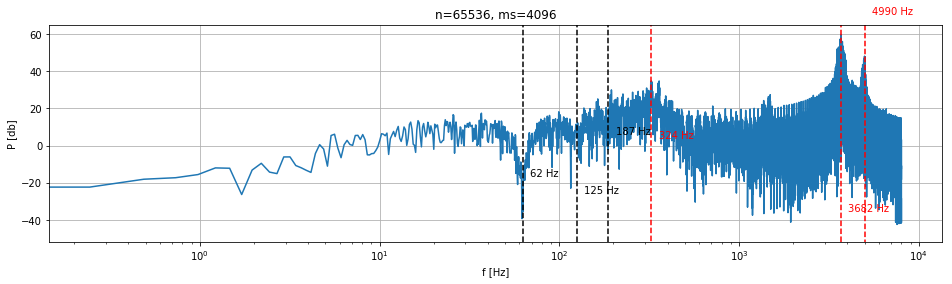

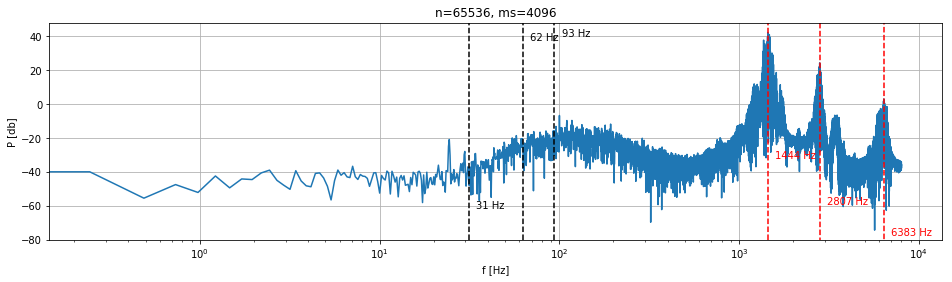

In [262]:

Rh_16ms = plot_freq(recording_16ms, min_secs=4)
annotate_peaks(Rh_16ms)
for i in range(1, 4):
    plothz(i * 1/16e-3, 'k')
# Rn_16ms = plot_freq(recording_16ms, min_secs=4, win=lambda x: 1, ax=plt.gca())

Rh_32ms = plot_freq(recording_32ms, min_secs=4)
annotate_peaks(Rh_32ms)
for i in range(1, 4):
    plothz(i * 1/32e-3, 'k')
# Rn_32ms = plot_freq(recording_32ms, min_secs=4, win=lambda x: 1, ax=plt.gca())


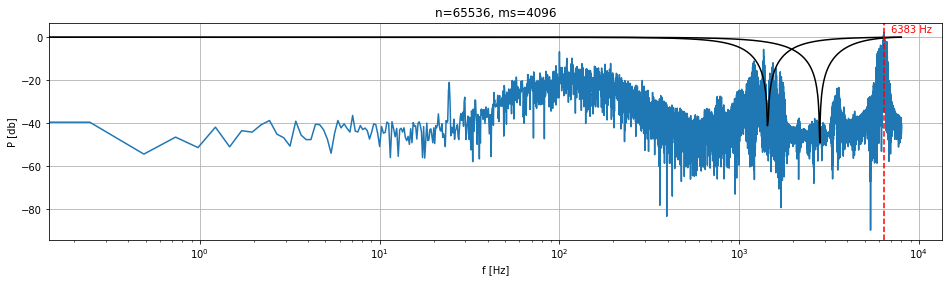

In [259]:
Rh_32ms_ = notchit(recording_32ms, [1444, 2807], min_secs=4)
annotate_peaks(Rh_32ms_)

In [264]:
r = live_loop(10.)

Recording 1e+01 secs hop_size=512 (8192000ms)


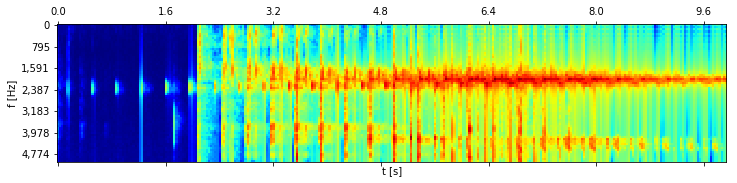

In [269]:
util.plot_logmel(features.log_mel_spectrogram(r))

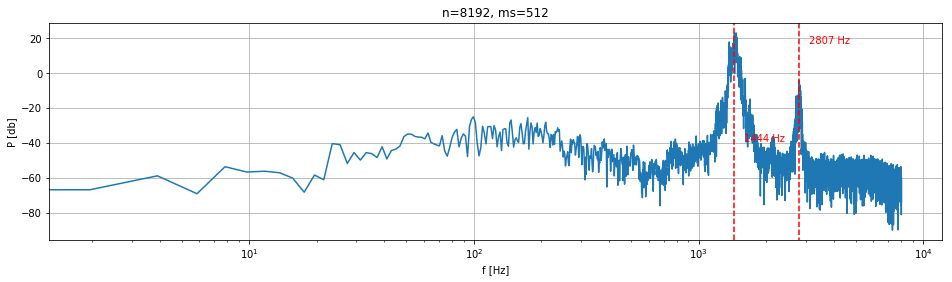

In [297]:
R = plot_freq(recording_32ms, min_secs=0.5, secs0=6)#, win=lambda x: 1)
annotate_peaks(R, dbneg=20)

# etc

## fix mel y axis

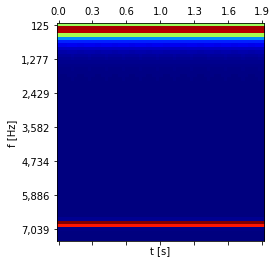

In [42]:
secs = 2
n = int(secs * settings.rate)
sig = np.zeros(n)
# for hz in (400, 800, 1600, 3200):
for hz in (200, 6000,):
    sig += np.sin(np.linspace(0, 2*np.pi*hz*secs, n)) * 0.1

util.plot_logmel(sig)
ax = plt.gca()

# WRONG !
def f2hz(f):
    hz0 = settings.lower_edge_hertz
    hzm = (settings.upper_edge_hertz / settings.lower_edge_hertz) ** (1 / settings.num_mel_bins)
    return hz0 * (hzm ** f)

# WRONG !
def mel2hz(mel):
    # https://en.wikipedia.org/wiki/Mel_scale
    return 700 * (np.exp(mel / 1127) - 1)

def f2hz(f):
    range_hertz = settings.upper_edge_hertz - settings.lower_edge_hertz
    mel = settings.lower_edge_hertz + (f / settings.num_mel_bins) * range_hertz
    return mel
    return mel2hz(mel)

ax.set_yticklabels([
    '{:,}'.format(int(f2hz(f)))
    for f in ax.get_yticks()
]);


In [23]:
settings.lower_edge_hertz, settings.upper_edge_hertz

(125, 7500)

In [22]:
[_ for _ in ax.get_yticks()]

[-10.0, 0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0]

In [34]:

f2hz(64)

7499.99999999997

In [21]:
[_ for _ in ax.get_yticklabels()]

[Text(0, -10.0, '-795'),
 Text(0, 0.0, '0'),
 Text(0, 10.0, '795'),
 Text(0, 20.0, '1,591'),
 Text(0, 30.0, '2,387'),
 Text(0, 40.0, '3,183'),
 Text(0, 50.0, '3,978'),
 Text(0, 60.0, '4,774'),
 Text(0, 70.0, '5,570')]

# end

In [ ]:
# ... way too slow !
%matplotlib  notebook

class Plotter:
    def __init__(self, n=100, figsize=(10, 5)):
        self.fig = plt.figure(figsize=figsize)
        self.ax = plt.gca()
#         plt.legend()
        self.data = dict()
        self.lines = dict()
        self.n = n
    def update(self, data):
        ymin, ymax = 1e10, -1e10
        for k, v in data.items():
            if k not in self.data:
                self.data[k] = np.zeros(self.n)
                self.lines[k], = self.ax.plot(self.data[k], label=k)
            self.data[k] = np.roll(self.data[k], shift=-1)
            self.data[k][self.n - 1] = v
            self.lines[k].set_ydata(self.data[k])
            ymin = min(ymin, self.data[k].min())
            ymax = max(ymax, self.data[k].max())
        if ymin != ymax:
            self.ax.set_ylim([ymin, ymax])
        self.fig.canvas.draw()

plotter = Plotter()
for i in range(100):
#     time.sleep(0.01)
    plotter.update(dict(a=i%5, b=(i%3)*.5))